In [229]:
import pandas as pd

file_path = "results.csv"

results = pd.read_csv(file_path)
results

,split,nome_modelo,dataset,tempo_tune,tempo_train,auc_ovo,mean_acc,g_mean,mean_cross_entropy,tempo_predict
0,train,AutoSklearn,breast-w,NaN,65.920298,0.998384,0.990909,0.991514,0.062397,0.413152
1,test,AutoSklearn,breast-w,NaN,65.920298,0.997808,0.976190,0.974575,0.089550,0.332620
2,train,AutoSklearn,eucalyptus,NaN,56.530461,0.954334,0.825714,0.789756,0.665422,3.786953
3,test,AutoSklearn,eucalyptus,NaN,56.530461,0.870681,0.670659,0.600649,0.854149,3.711598
4,train,AutoSklearn,wdbc,NaN,54.669093,0.996147,0.988827,0.986607,0.075828,0.423970
...,...,...,...,...,...,...,...,...,...,...
355,test,XGBoost,ilpd,0.847443,0.012590,0.670589,0.678638,0.494016,0.581657,0.000335
356,train,XGBoost,cnae-9,30.406674,0.564654,0.998571,0.951471,0.951793,0.253978,0.013318
357,test,XGBoost,cnae-9,30.406674,0.564654,0.992460,0.902941,0.901391,0.386640,0.003938
358,train,XGBoost,vowel,13.596269,0.434183,1.000000,1.000000,1.000000,0.057559,0.036703


In [230]:
train_results = results[results["split"] == "train"]
train_results.tail()

,split,nome_modelo,dataset,tempo_tune,tempo_train,auc_ovo,mean_acc,g_mean,mean_cross_entropy,tempo_predict
350,train,XGBoost,cylinder-bands,1.045033,0.014454,0.999711,0.988971,0.986793,0.259161,0.001199
352,train,XGBoost,semeion,22.142984,0.624991,1.000000,1.000000,1.000000,0.018892,0.021236
354,train,XGBoost,ilpd,0.847443,0.012590,0.863049,0.805191,0.663558,0.427549,0.000799
356,train,XGBoost,cnae-9,30.406674,0.564654,0.998571,0.951471,0.951793,0.253978,0.013318
358,train,XGBoost,vowel,13.596269,0.434183,1.000000,1.000000,1.000000,0.057559,0.036703


In [231]:
test_results = results[results["split"] == "test"]
test_results.tail()

,split,nome_modelo,dataset,tempo_tune,tempo_train,auc_ovo,mean_acc,g_mean,mean_cross_entropy,tempo_predict
351,test,XGBoost,cylinder-bands,1.045033,0.014454,0.793482,0.702941,0.663649,0.545985,0.000441
353,test,XGBoost,semeion,22.142984,0.624991,0.994077,0.910289,0.905900,0.291378,0.005500
355,test,XGBoost,ilpd,0.847443,0.012590,0.670589,0.678638,0.494016,0.581657,0.000335
357,test,XGBoost,cnae-9,30.406674,0.564654,0.992460,0.902941,0.901391,0.386640,0.003938
359,test,XGBoost,vowel,13.596269,0.434183,0.990973,0.876232,0.866395,0.450785,0.009292


# statistics for train datasets

Estamos testando:
- H₀ (hipótese nula): todos os modelos têm desempenho equivalente.
    - Ou seja: as diferenças nos ranks médios são apenas devido ao acaso.

- H₁ (hipótese alternativa): pelo menos um modelo tem desempenho sistematicamente diferente.

In [232]:
import pandas as pd
import numpy as np
from scipy.stats import friedmanchisquare, rankdata
from math import sqrt
from itertools import combinations
from scipy.stats import norm

df_avg = train_results.groupby(["dataset", "nome_modelo"])["g_mean"].mean().reset_index()

table = df_avg.pivot(index="dataset", columns="nome_modelo", values="g_mean")
table = table.dropna()

models = list(table.columns)
datasets = list(table.index)
k = len(models)
N = len(datasets)

print(f"Comparando {k} modelos e {N} datasets")

Comparando 6 modelos e 30 datasets


In [233]:
# 2. CALCULAR RANKS POR DATASET

ranks = table.rank(axis=1, ascending=False)  # maior g-mean = melhor rank (1)
avg_ranks = ranks.mean()

print("\n===== Average Ranks =====")
print(avg_ranks)


===== Average Ranks =====
nome_modelo
AutoGulon      5.916667
AutoSklearn    2.616667
CatBoost       1.683333
LightGBM       4.533333
XGBoost        2.800000
t2g-former     3.450000
dtype: float64


O que foi feito: 

- Ordenado os modelos pela métrica G-Mean
- O melhor modelo no dataset recebe rank 1, o segundo melhor rank 2, e assim por diante
- Depois, é calculada a média desses ranks de cada modelo ao longo de todos os datasets.

Ou seja, os número exibidos são as médias dos ranks.

**Detalhe**:
Quanto MENOR o rank médio, melhor o modelo.
- Rank médio 1.0 → o modelo foi sempre o melhor em todos os datasets.
- Rank médio perto de k → o modelo foi quase sempre o pior.

Interpretando os seus resultados:

1. CatBoost - 1.683333
    - Ficou entre o 1o e o 2o lugar nos datasets.
    - É o melhor modelo globalmente.

2. AutoSklearn – 2.616667
    - Em média, ficou entre 2o e 3o lugar nos datasets.
    - Segundo melhor modelo

3. XGBoost - 2.8
    - Entre o 2o e 3o lugar.

4. t2g-former – 3.45
    - Fica em média entre a 3a e 4a posição.

3. LightGBM – 4.533333
    - Em média entre 4o e 5o lugar.
    - Desempenho intermediário.

4. AutoGluon – 5.916667
    - Quase k, ou seja, em muitos datasets ele foi o pior de todos.

In [236]:
# 3. FRIEDMAN TEST

stats = [ranks[col].values for col in models]
friedman_stat, friedman_p = friedmanchisquare(*stats)

print("\n===== Friedman Test =====")
print(f"Statistic: {friedman_stat:.4f}")
print(f"P-value: {friedman_p:.4f}")


===== Friedman Test =====
Statistic: 99.2603
P-value: 0.0000


Esse valor do Friedman mede quão diferentes os ranks são.

Para 6 modelos (k = 6), valores abaixo de ~8–9 tenderiam a não rejeitar H₀.

Mas 99.26 é gigante, ou seja:
- Os modelos têm ranks extremamente diferentes entre si.

Sobre o p-value:
- O p-value NÃO é exatamente zero, mas é um número muito pequeno e o Python arredondou para 0.
- Isso significa que as chances das diferenças observadas serem aleatórias são praticamente nulas.

Interpretação dos resultados:
- p-value pequeno (< 0.000001)
- Valor estatístico alto (99.26)
- Então:
    - REJEITA a hipótese nula.
    - Portanto:
        - Os classificadores NÃO têm desempenho equivalente. Existem diferenças estatisticamente significativas entre eles.

In [237]:
# 4. NEMENYI POST-HOC

q_alpha = 2.850   # para k=4 e alfa=0.05 (Tabela 5a)
CD = q_alpha * sqrt(k*(k+1)/(6*30))

print("Nemenyi Critical Difference")
print(f"CD = {CD:.4f}")

nemenyi_results = {}

for m1, m2 in combinations(models, 2):
    diff = abs(avg_ranks[m1] - avg_ranks[m2])
    nemenyi_results[(m1, m2)] = diff > CD

print("Nemenyi Significant Pairs (p<0.05)")

for (m1, m2), sig in nemenyi_results.items():
    if sig:
        print(f"{m1} vs {m2} → SIGNIFICANTE")


Nemenyi Critical Difference
CD = 1.3767
Nemenyi Significant Pairs (p<0.05)
AutoGulon vs AutoSklearn → SIGNIFICANTE
AutoGulon vs CatBoost → SIGNIFICANTE
AutoGulon vs LightGBM → SIGNIFICANTE
AutoGulon vs XGBoost → SIGNIFICANTE
AutoGulon vs t2g-former → SIGNIFICANTE
AutoSklearn vs LightGBM → SIGNIFICANTE
CatBoost vs LightGBM → SIGNIFICANTE
CatBoost vs t2g-former → SIGNIFICANTE
LightGBM vs XGBoost → SIGNIFICANTE


O Critical Difference é o quanto dois ranks médios precisam diferir para que a diferença seja considerada estatisticamente significativa (p < 0.05).

Grupo de modelos estatisticamente sem diferenças detectáveis:

    - AutoSklearn
    - t2g-former
    - CatBoost
    -  XGBoost

AutoGluon é estatisticamente pior que todos os outros modelos.

Interpretação dos resultados:
- O teste de Nemenyi identificou um Critical Difference (CD = 1.3767), indicando o limiar mínimo de diferença de ranks para significância estatística.
- AutoGluon foi estatisticamente pior do que todos os outros modelos, sendo o único algoritmo que se destacou consistentemente como significativamente inferior.
- AutoSklearn, t2g-former, CatBoost e XGBoost formam um grupo estatisticamente equivalente, ou seja, suas diferenças de desempenho não ultrapassaram o limite necessário para significância. Esses modelos podem ser considerados de desempenho semelhante.
- LightGBM apresentou desempenho inferior a vários modelos (AutoSklearn, CatBoost, t2g-former e XGBoost), mas não tão ruim quanto AutoGluon. Assim, ele forma um “grupo intermediário”.
- Entre os melhores modelos, as únicas diferenças estatisticamente significativas foram contra LightGBM (que ficou abaixo) e contra AutoGluon (o pior). As demais combinações não mostraram diferença significativa.

In [239]:
models

['AutoGulon', 'AutoSklearn', 'CatBoost', 'LightGBM', 'XGBoost', 't2g-former']

In [240]:
# 5. HOLM POST-HOC (controle)

baseline = models[-1]
print(f"Baseline: {baseline}")

# estatística z = (Ri - Rj) / SE
SE = sqrt(k*(k+1)/(6*30))

holm_raw = {}

for m in models:
    if m == baseline:
        continue

    z = abs(avg_ranks[m] - avg_ranks[baseline]) / SE
    p = 2*(1 - norm.cdf(z))
    holm_raw[m] = p

# ordenar p-values
sorted_holm = sorted(holm_raw.items(), key=lambda x: x[1])

print("Holm Post-Hoc")

for i, (model, p) in enumerate(sorted_holm, start=1):
    threshold = 0.05 / (k - i)
    decision = "REJEITA" if p < threshold else "NÃO REJEITA"

    print(f"{model:20s} p={p:.6f}  lim={threshold:.6f} → {decision}")

Baseline: t2g-former
Holm Post-Hoc
AutoGulon            p=0.000000  lim=0.010000 → REJEITA
CatBoost             p=0.000255  lim=0.012500 → REJEITA
LightGBM             p=0.024915  lim=0.016667 → NÃO REJEITA
AutoSklearn          p=0.084498  lim=0.025000 → NÃO REJEITA
XGBoost              p=0.178423  lim=0.050000 → NÃO REJEITA


O que é o Holm Post-Hoc?
- Depois que o teste de Friedman detecta que há diferenças significativas entre os modelos, o teste de Holm serve para comparar um modelo de referência (baseline) com todos os outros, controlando FWER (Family-wise Error Rate).

Em suma, o Holm testa se um modelo é estatisticamente diferente do baseline.

Para cada par:
- p-value vem das diferenças dos ranks entre cada modelo e o baseline lmite é o limiar ajustado de Holm
- Se p <= limite → rejeita H₀ → diferença significativa
- Se p > limite → não rejeita → não há diferença significativa


Se "REJEITA": desempenho **estatisticamente pior** do que o baseline (t2g-former).
Se "NÃO REJEITA": **equivalente** ao baseline.


Resumo geral (Friedman + Nemenyi + Holm)

**AutoGluon**
* Estatisticamente pior que todos os outros modelos.
* Rejeitado no teste de Holm contra o baseline (t2g-former).
* Consistentemente inferior em todas as análises.
* **Conclusão:** pior modelo do conjunto.

**CatBoost**
* Rejeitado no teste de Holm: **estatisticamente pior que o t2g-former**.
* No Nemenyi, também perdeu para LightGBM, AutoSklearn e t2g-former.
* **Conclusão:** desempenho bom, mas inferior aos líderes.

**LightGBM**
* No Nemenyi: inferior ao AutoSklearn e ao CatBoost.
* No Holm: **não inferior ao t2g-former** (equivalente estatisticamente).
* Representa um nível intermediário: pior que alguns, equivalente a outros.
* **Conclusão:** desempenho mediano, consistente, mas não líder.

**AutoSklearn**
* Melhor rank médio geral entre todos os modelos.
* No Nemenyi: superior ao LightGBM.
* No Holm: **equivalente ao t2g-former**.
* Não há diferença estatística entre AutoSklearn e t2g-former.
* **Conclusão:** um dos melhores modelos, tecnicamente empatado com t2g-former.

**XGBoost**
* No Nemenyi: perdeu para LightGBM em apenas um caso isolado.
* No Holm: **equivalente ao t2g-former**.
* Estatisticamente próximo dos melhores modelos.
* **Conclusão:** desempenho estável e competitivo.

**t2g-former (baseline)**

* No Friedman e Nemenyi: está entre os modelos de maior desempenho.
* No Holm: estatisticamente equivalente a AutoSklearn, LightGBM e XGBoost.
* CatBoost e AutoGluon são estatisticamente piores.
* **Conclusão:** modelo forte, segundo grupo superior da comparação.

Em outras palavras:
* **Grupo Superior (estatisticamente equivalentes):**
  **t2g-former, AutoSklearn, XGBoost, LightGBM**
  - Não apresentam diferenças significativas entre si no teste de Holm.

* **Grupo Intermediário:**
  **CatBoost**
  - Estatisticamente pior que o t2g-former, mas ainda competitivo.

* **Pior Modelo:**
  **AutoGluon**
  - Significativamente pior que todos os demais em todos os testes.


## Plots

/var/folders/xh/n_j2f34x3gbbkjmhhfy63yc00000gn/T/ipykernel_31316/1937962928.py:18: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  avg_ranks = avg_ranks[order]


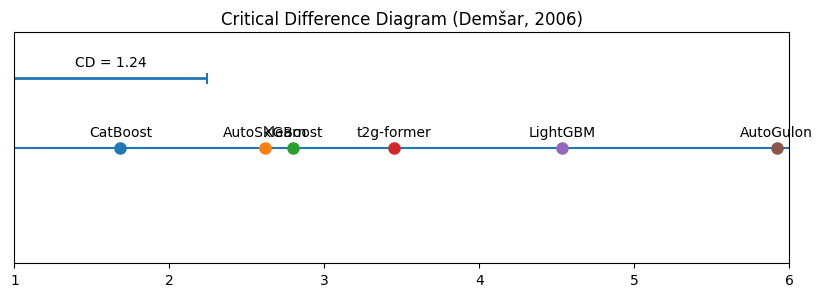

In [219]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scikit_posthocs as sp
from scipy.stats import friedmanchisquare, norm
import math

df = train_results

pivot = df.pivot(index="dataset", columns="nome_modelo", values="g_mean")

models = list(pivot.columns)
N = pivot.shape[0]
k = len(models)

def critical_difference_plot(avg_ranks, names, cd):
    order = np.argsort(avg_ranks)
    avg_ranks = avg_ranks[order]
    names = [names[i] for i in order]

    fig, ax = plt.subplots(figsize=(10, 3))
    ax.set_xlim(1, k)
    ax.set_ylim(0, 2)
    ax.set_yticks([])

    ax.hlines(1, 1, k)

    for i, (rank, name) in enumerate(zip(avg_ranks, names)):
        ax.plot(rank, 1, 'o', markersize=8)
        ax.text(rank, 1.1, name, ha='center', fontsize=10)

    ax.hlines(1.6, 1, 1 + cd, linewidth=2)
    ax.vlines(1, 1.55, 1.65)
    ax.vlines(1 + cd, 1.55, 1.65)
    ax.text(1 + cd / 2, 1.7, f"CD = {cd:.2f}", ha='center')

    plt.title("Critical Difference Diagram (Demšar, 2006)", fontsize=12)
    plt.savefig("cd_plot.png", dpi=300, bbox_inches="tight")
    plt.show()


critical_difference_plot(avg_ranks, models, CD)

In [220]:
import pandas as pd
import numpy as np
import scikit_posthocs as sp
from scipy.stats import friedmanchisquare, norm
import math

df = train_results

pivot = df.pivot(index="dataset", columns="nome_modelo", values="g_mean")

models = list(pivot.columns)
N = pivot.shape[0]
k = len(models)

stat, p = friedmanchisquare(*[pivot[col] for col in models])
print("Friedman Test")
print("Stat =", stat, "p =", p)

# Nemenyi (matriz completa)
nemenyi = sp.posthoc_nemenyi_friedman(pivot.values)
nemenyi.columns = models
nemenyi.index = models

print("\n=== Nemenyi Matrix ===")
print(nemenyi)

# Holm vs baseline (t2g-former)
baseline = "t2g-former"

ranks = pivot.rank(axis=1, ascending=False)
avg_ranks = ranks.mean()

SE = math.sqrt(k * (k + 1) / (6 * N))

pvals = {}

for model in models:
    if model == baseline:
        continue

    diff = abs(avg_ranks[model] - avg_ranks[baseline])
    z = diff / SE
    pval = 2 * (1 - norm.cdf(abs(z)))
    pvals[model] = pval

sorted_models = sorted(pvals, key=pvals.get)
m = len(sorted_models)

holm_limits = {model: 0.05 / (m - i) for i, model in enumerate(sorted_models)}

holm_df = pd.DataFrame({
    "model": sorted_models,
    "p_value": [pvals[m] for m in sorted_models],
    "holm_limit": [holm_limits[m] for m in sorted_models],
})

holm_df["reject_null"] = holm_df["p_value"] < holm_df["holm_limit"]

print("Holm (baseline =", baseline, ")")
print(holm_df)


Friedman Test
Stat = 99.26032660902985 p = 7.567193797890192e-20

=== Nemenyi Matrix ===
                AutoGulon   AutoSklearn      CatBoost      LightGBM  \
AutoGulon    1.000000e+00  1.258862e-10  0.000000e+00  4.805008e-02   
AutoSklearn  1.258862e-10  1.000000e+00  3.823028e-01  1.023228e-03   
CatBoost     0.000000e+00  3.823028e-01  1.000000e+00  5.440024e-08   
LightGBM     4.805008e-02  1.023228e-03  5.440024e-08  1.000000e+00   
XGBoost      1.653567e-09  9.989817e-01  1.891656e-01  4.492597e-03   
t2g-former   4.877970e-06  5.149608e-01  3.473614e-03  2.182088e-01   

                  XGBoost  t2g-former  
AutoGulon    1.653567e-09    0.000005  
AutoSklearn  9.989817e-01    0.514961  
CatBoost     1.891656e-01    0.003474  
LightGBM     4.492597e-03    0.218209  
XGBoost      1.000000e+00    0.759397  
t2g-former   7.593967e-01    1.000000  
Holm (baseline = t2g-former )
         model       p_value  holm_limit  reject_null
0    AutoGulon  3.282064e-07    0.010000         

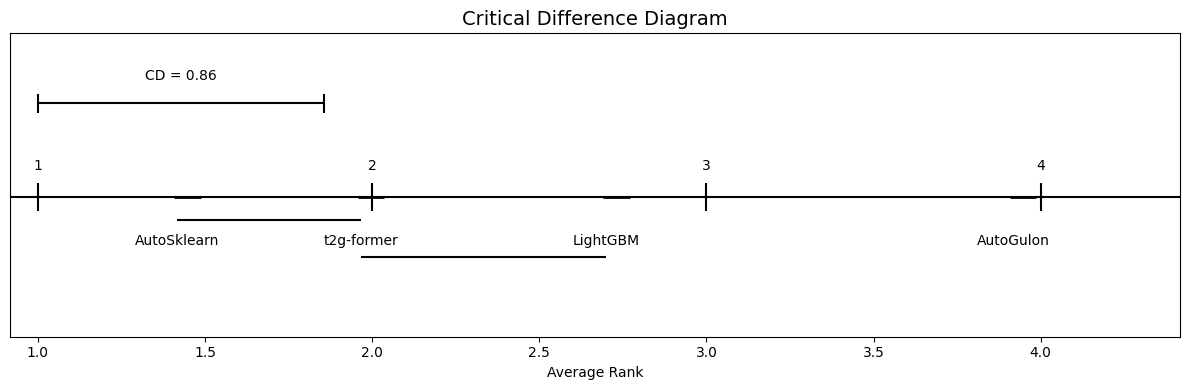

In [221]:
import numpy as np
import matplotlib.pyplot as plt

def plot_cd_demsar(avg_ranks, cd, groups=None, title="Critical Difference Diagram"):
    """
    avg_ranks: dict -> {model: rank}
    cd: float → critical difference
    groups: list of lists → modelos que NÃO são significativamente diferentes
    """
    
    models = list(avg_ranks.keys())
    ranks  = np.array([avg_ranks[m] for m in models])
    
    order = np.argsort(ranks)
    models = [models[i] for i in order]
    ranks  = ranks[order]

    k = len(models)

    fig, ax = plt.subplots(figsize=(12, 4))
    
    ax.hlines(1, ranks.min() - 0.5, ranks.max() + 0.5, color="black")
    
    # Marcações de rank (no topo)
    for r in range(1, k+1):
        ax.text(r, 1.05, str(r), ha="center", va="bottom", fontsize=10)
        ax.vlines(r, 1 - 0.03, 1 + 0.03, color="black")

    ax.hlines(1.20, 1, 1 + cd, color="black")
    ax.vlines(1, 1.18, 1.22, color="black")
    ax.vlines(1 + cd, 1.18, 1.22, color="black")
    ax.text(1 + cd/2, 1.25, f"CD = {cd:.2f}", ha="center")

    for model, r in zip(models, ranks):
        ax.hlines(1, r - 0.01, r + 0.07, color="black", linewidth=2)
        ax.text(r, 0.92, model, ha="center", va="top", fontsize=10)

    if groups:
        y_group = 0.95

        for g in groups:
            idx = [models.index(m) for m in g]
            left  = ranks[idx].min()
            right = ranks[idx].max()
            ax.hlines(y_group, left, right, color="black", linewidth=1.5)
            y_group -= 0.08 

    ax.set_ylim(0.7, 1.35)
    ax.set_xlim(ranks.min() - 0.5, ranks.max() + 0.5)
    ax.set_yticks([])
    ax.set_xlabel("Average Rank")
    ax.set_title(title, fontsize=14)

    plt.tight_layout()
    plt.show()

avg_ranks = {
    "AutoSklearn": 1.416667,
    "t2g-former": 1.966667,
    "LightGBM": 2.700000,
    "AutoGulon": 3.916667
}

cd = 0.8563333333333333

groups = [
    ["AutoSklearn", "t2g-former"],
    ["t2g-former", "LightGBM"],
]

plot_cd_demsar(avg_ranks, cd, groups)

A imagem mostra o **ranking médio** dos quatro modelos testados considerando todos os datasets, além da **Critical Difference (CD = 0.86)** do teste de Nemenyi.

Nessa imagem:
- AutoSklearn aparece como melhor modelo global.
    - Ele aparece com o **menor rank médio**.
    - Em diagramas de CD, **quanto menor o rank melhor o modelo**.
    - **AutoSklearn foi o que apresentou performance mais consistente entre todos os datasets.**

- t2g-former é o segundo melhor.
    - Tem rank médio **2.0**, próximo do AutoSklearn.
    - A diferença entre AutoSklearn e t2g-former é **menor do que a CD**, portanto **não é estatisticamente significativa**.
    - Isso quer dizer:
        - Ambos têm desempenhos semelhantes.
        - Não podemos afirmar que AutoSklearn supera t2g-former com 95% de confiança.

- LightGBM aparece em terceiro lugar
    - Está **estatisticamente pior que AutoSklearn**.
    - Pode estar **ligeiramente pior que t2g-former**, dependendo dos ranks exatos — mas na imagem ele aparenta estar **fora do intervalo significativo**.

- AutoGluon é o pior modelo de todos**

Rank médio **≈ 3.9**, bem distante dos demais.


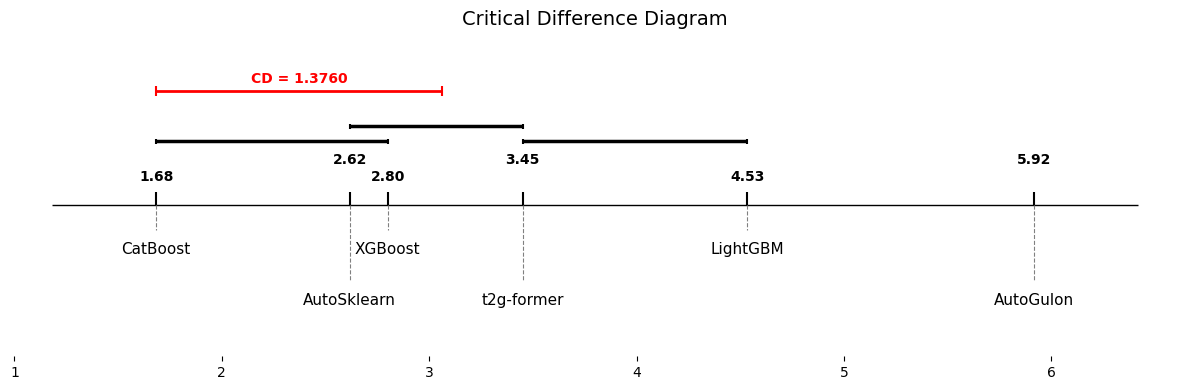

In [242]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.transforms as mtransforms

def plot_cd_diagram_adjusted(avg_ranks, cd, title="Critical Difference Diagram"):
    """
    Gera o diagrama de CD com ajuste automático de sobreposição de texto
    usando escalonamento vertical alternado.
    """

    sorted_ranks = sorted(avg_ranks.items(), key=lambda x: x[1])
    models = [item[0] for item in sorted_ranks]
    ranks = np.array([item[1] for item in sorted_ranks])
    k = len(models)

    groups = []

    for i in range(k):
        for j in range(k-1, i, -1):
            if ranks[j] - ranks[i] < cd:
                groups.append((i, j))

                break

    # Filtrar subgrupos redundantes
    final_groups = []

    for g1 in groups:
        is_subgroup = False

        for g2 in groups:
            if g1 != g2 and g1[0] >= g2[0] and g1[1] <= g2[1]:
                is_subgroup = True
                break

        if not is_subgroup:
            final_groups.append(g1)
            
    fig, ax = plt.subplots(figsize=(12, 4))
    
    x_min = ranks.min()
    x_max = ranks.max()
    
    ax.set_xlim(x_min - 0.7, x_max + 0.7)
    ax.set_ylim(0.0, 1.2)
    
    main_line_y = 0.6
    
    ax.hlines(main_line_y, x_min - 0.5, x_max + 0.5, color="black", linewidth=1)
    
    
    for i, (model, r) in enumerate(zip(models, ranks)):
        ax.vlines(r, main_line_y, main_line_y + 0.05, color="black")
        
        rank_text_y = main_line_y + 0.08 if i % 2 == 0 else main_line_y + 0.15
        
        ax.text(r, rank_text_y, f"{r:.2f}", ha="center", va="bottom", fontsize=10, fontweight='bold')
        
        if i % 2 == 0:
            model_text_y = main_line_y - 0.15
            connector_y = model_text_y + 0.05
        else:
            model_text_y = main_line_y - 0.35
            connector_y = model_text_y + 0.05

        ax.plot([r, r], [main_line_y, connector_y], color="gray", linestyle="--", linewidth=0.8)
        ax.text(r, model_text_y, model, ha="center", va="top", fontsize=11)


    cd_y_pos = 1.05
    ax.hlines(cd_y_pos, x_min, x_min + cd, color="red", linewidth=2)
    ax.vlines(x_min, cd_y_pos - 0.02, cd_y_pos + 0.02, color="red")
    ax.vlines(x_min + cd, cd_y_pos - 0.02, cd_y_pos + 0.02, color="red")
    ax.text(x_min + cd/2, cd_y_pos + 0.03, f"CD = {cd:.4f}", ha="center", color="red", fontweight='bold')


    base_group_y = main_line_y + 0.25
    step_y = 0.06
    
    final_groups.sort(key=lambda x: x[1]-x[0]) 
    occupied_levels = [] 

    for start_idx, end_idx in final_groups:
        left_val = ranks[start_idx]
        right_val = ranks[end_idx]
        
        level = 0

        while True:
            collision = False

            for (occ_left, occ_right, occ_level) in occupied_levels:
                if occ_level == level:
                    if not (right_val < occ_left - 0.05 or left_val > occ_right + 0.05):
                        collision = True
                        break

            if not collision:
                break

            level += 1
        
        occupied_levels.append((left_val, right_val, level))
        
        y_pos = base_group_y + level * step_y
        ax.hlines(y_pos, left_val, right_val, color="black", linewidth=2.5)
        ax.vlines(left_val, y_pos - 0.01, y_pos + 0.01, color="black")
        ax.vlines(right_val, y_pos - 0.01, y_pos + 0.01, color="black")

    ax.set_yticks([])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.set_title(title, fontsize=14, pad=20)
    
    plt.tight_layout()
    plt.show()

avg_ranks = {
    "AutoSklearn": 2.616667,
    "t2g-former":  3.450000,
    "LightGBM": 4.533333,
    "AutoGulon":  5.916667,
    "CatBoost": 1.683333,
    "XGBoost": 2.800000
}

cd = 1.376

plot_cd_diagram_adjusted(avg_ranks, cd)

O gráfico mostra os **ranks médios** dos 6 modelos avaliados ao longo dos datasets, juntamente com o **intervalo crítico (CD = 1.376)** — que determina quando diferenças são **estatisticamente significativas** pelo teste de Nemenyi.

**Grupo estatisticamente equivalente (grupo superior):**
* **CatBoost (1.68)**
* **XGBoost (2.80)**
* **AutoSklearn (2.62)**

Esses três modelos **não diferem estatisticamente entre si**.
- Eles formam um grupo de desempenho similar.

**2. Quem é significativamente pior?**
Quando o rank médio está **CD acima** do outro, há diferença significativa.

**LightGBM (4.53)**
* Há diferença clara entre LightGBM e os três melhores (CatBoost, AutoSklearn, XGBoost).
  -  **LightGBM é pior que o grupo superior.**

**AutoGluon (5.92)**
* Fica bem além de todos os intervalos.
  - **É significativamente pior que todos os outros modelos.**

**CatBoost** tem o *menor rank médio* (1.68), sugerindo que:
* Foi o modelo mais frequente no topo dos datasets.
* É o melhor modelo em termos de rank.

Resumo:
* **Melhor desempenho (empate técnico entre 3 modelos):**
  **CatBoost, AutoSklearn, XGBoost**

* **Desempenho intermediário:**
  **LightGBM** (estatisticamente pior que o grupo superior)

* **Pior modelo:**
  **AutoGluon** (significativamente pior que todos)


### extra plots

In [97]:
df = train_results

metrics = ["auc_ovo", "mean_acc", "g_mean", "mean_cross_entropy"]

results = {}
for m in metrics:
    results[m] = df[df["split"]=="train"].groupby("nome_modelo")[m].mean().sort_values(ascending=False)

pd.DataFrame(results)


,auc_ovo,mean_acc,g_mean,mean_cross_entropy
nome_modelo,,,,
AutoGulon,0.838251,0.745067,0.404518,0.812158
AutoSklearn,0.944774,0.914652,0.842496,0.478615
LightGBM,0.889410,0.837479,0.755742,0.585106
t2g-former,0.929302,0.871490,0.797996,0.292221


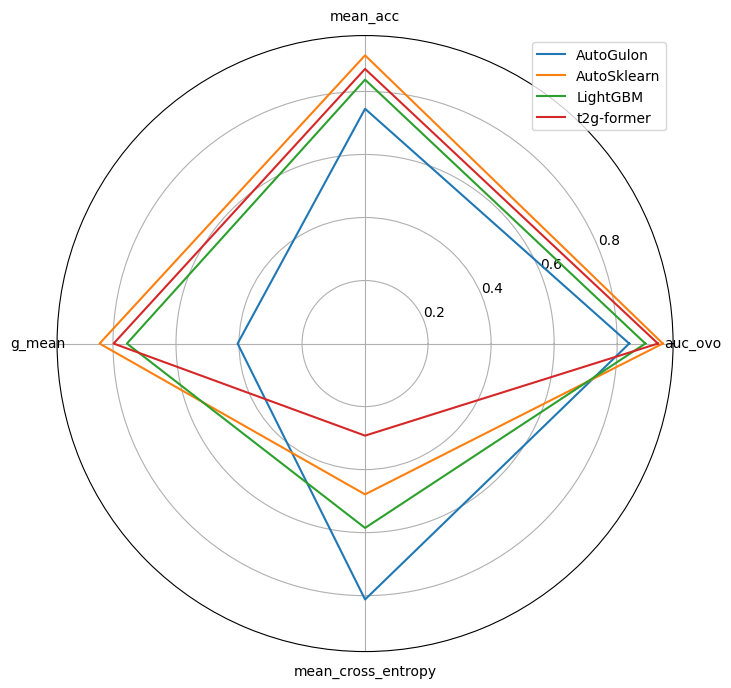

In [99]:
import matplotlib.pyplot as plt
import numpy as np

df = train_results
test = df[df["split"]=="train"].groupby("nome_modelo").mean(numeric_only=True)

metrics = ["auc_ovo","mean_acc","g_mean","mean_cross_entropy"]
labels = metrics

values = test[metrics].values.tolist()
names = test.index.tolist()

angles = np.linspace(0, 2*np.pi, len(labels), endpoint=False).tolist()
angles += angles[:1]

plt.figure(figsize=(8,8))
ax = plt.subplot(111, polar=True)

for i, name in enumerate(names):
    v = values[i]
    v = np.concatenate((v,[v[0]]))
    ax.plot(angles, v, label=name)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels)
plt.legend()
plt.show()

<Axes: xlabel='tempo_total', ylabel='g_mean'>

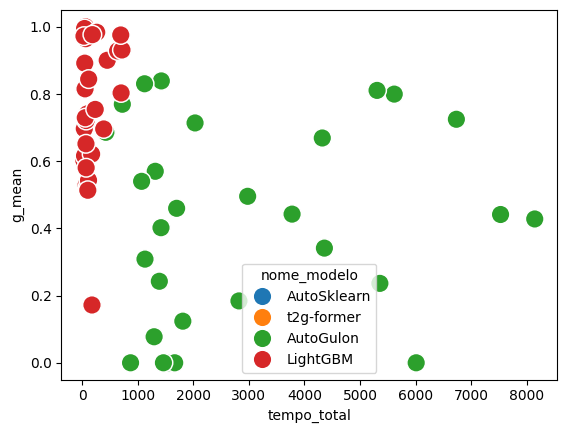

In [101]:
import seaborn as sns

test["tempo_total"] = test["tempo_tune"] + test["tempo_train"] + test["tempo_predict"]

sns.scatterplot(data=test, x="tempo_total", y="g_mean", hue="nome_modelo", s=180)

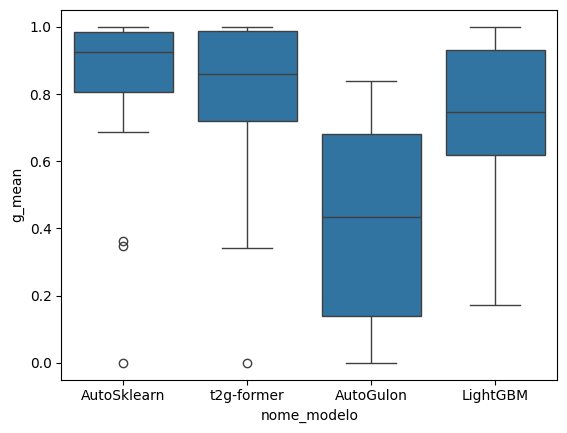

In [102]:
sns.boxplot(data=df[df["split"]=="train"], x="nome_modelo", y="g_mean")
plt.show()

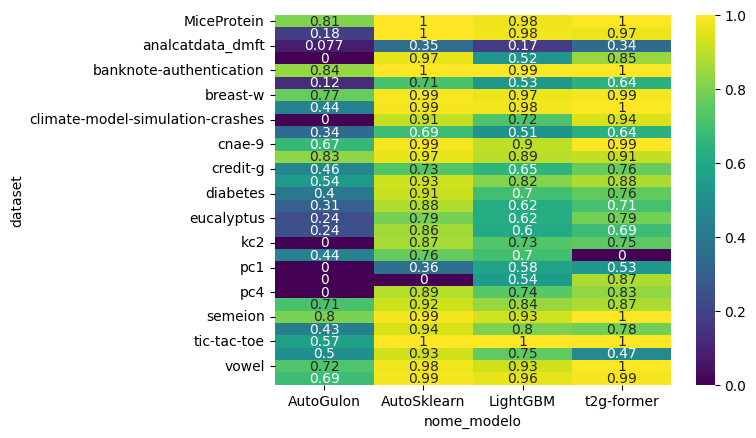

In [103]:
pivot = df[df["split"]=="train"].pivot(index="dataset", columns="nome_modelo", values="g_mean")

sns.heatmap(pivot, annot=True, cmap="viridis")
plt.show()

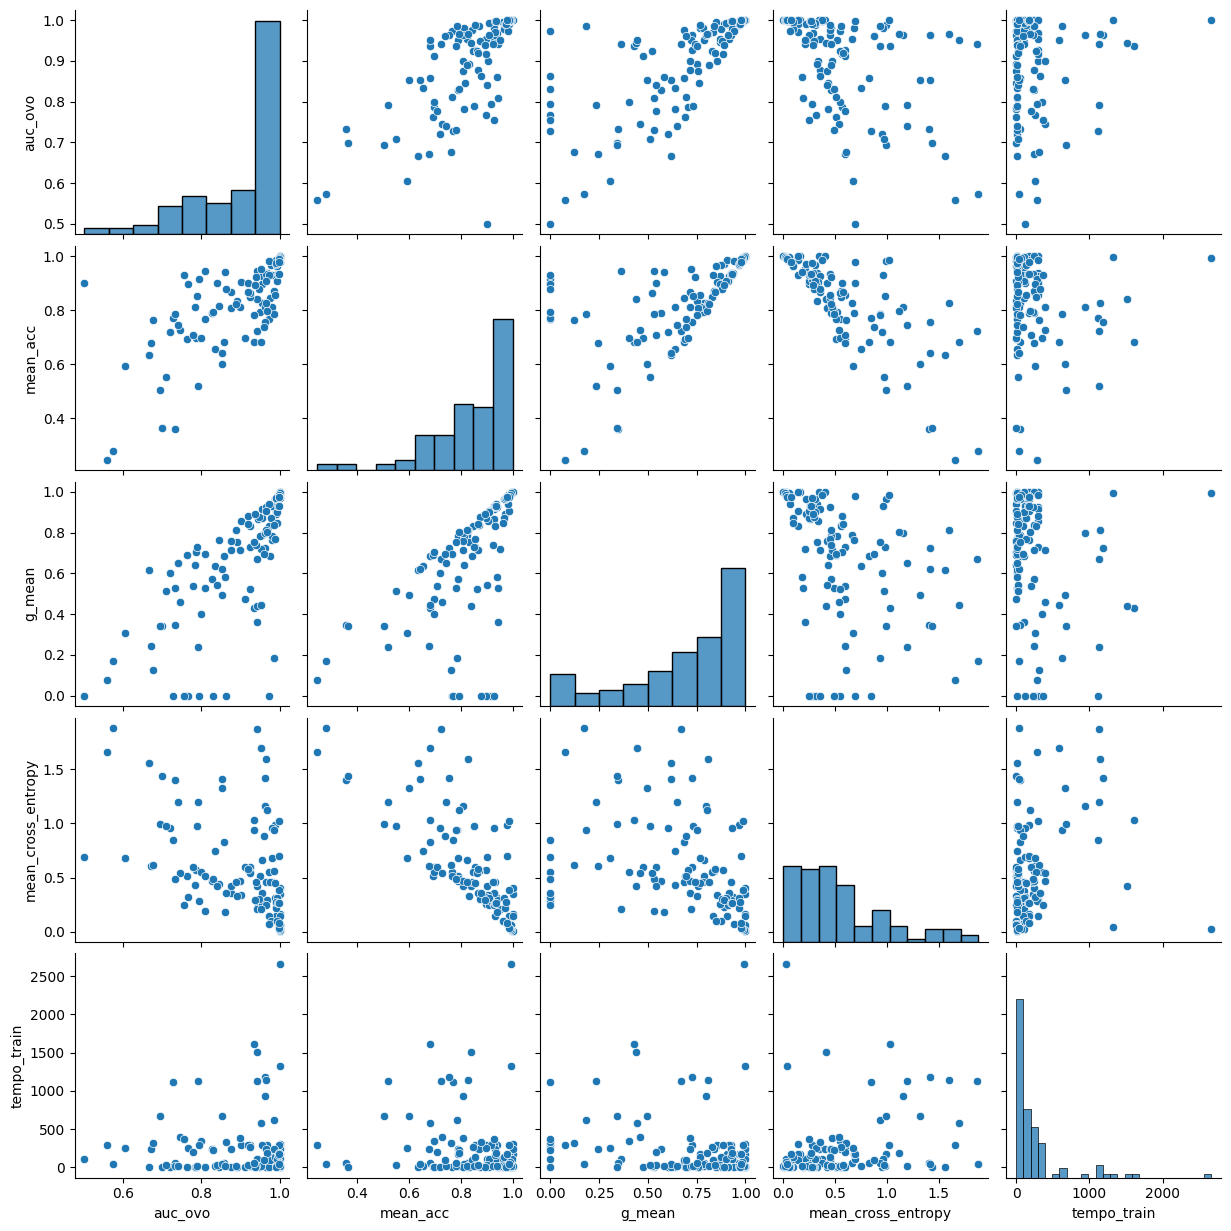

In [104]:
test = df[df["split"]=="train"]

sns.pairplot(test[["auc_ovo","mean_acc","g_mean","mean_cross_entropy","tempo_train"]])
plt.show()

,split,nome_modelo,dataset,tempo_tune,tempo_train,auc_ovo,mean_acc,g_mean,mean_cross_entropy,tempo_predict
0,train,AutoSklearn,breast-w,NaN,65.920298,0.998384,0.990909,0.991514,0.062397,0.413152
2,train,AutoSklearn,eucalyptus,NaN,56.530461,0.954334,0.825714,0.789756,0.665422,3.786953
4,train,AutoSklearn,wdbc,NaN,54.669093,0.996147,0.988827,0.986607,0.075828,0.423970
6,train,AutoSklearn,pc4,NaN,115.232249,0.990809,0.969499,0.890082,0.224395,5.328887
8,train,AutoSklearn,credit-g,NaN,294.931927,0.925386,0.853968,0.727698,0.598647,0.519495
...,...,...,...,...,...,...,...,...,...,...
230,train,LightGBM,vowel,411.52,160.190000,0.996961,0.933623,0.928316,0.263595,68.120000
232,train,LightGBM,analcatdata_dmft,112.04,45.090000,0.572763,0.279186,0.171989,1.881605,21.140000
234,train,LightGBM,semeion,460.67,182.910000,0.997311,0.934492,0.930987,0.268843,74.120000
236,train,LightGBM,MiceProtein,448.35,178.070000,0.999489,0.978842,0.975627,0.078542,69.510000


# statistics for test datasets

In [243]:
results_path = "results.csv"
results = pd.read_csv(results_path)

test_results = results[results["split"] == "test"]
test_results.head()

,split,nome_modelo,dataset,tempo_tune,tempo_train,auc_ovo,mean_acc,g_mean,mean_cross_entropy,tempo_predict
1,test,AutoSklearn,breast-w,NaN,65.920298,0.997808,0.976190,0.974575,0.089550,0.332620
3,test,AutoSklearn,eucalyptus,NaN,56.530461,0.870681,0.670659,0.600649,0.854149,3.711598
5,test,AutoSklearn,wdbc,NaN,54.669093,0.998089,0.988304,0.983999,0.079230,0.406010
7,test,AutoSklearn,pc4,NaN,115.232249,0.927329,0.897260,0.577596,0.310648,3.910934
9,test,AutoSklearn,credit-g,NaN,294.931927,0.772701,0.733333,0.488094,0.627840,0.322403


Estamos testando:
- H₀ (hipótese nula): todos os modelos têm desempenho equivalente.
    - Ou seja: as diferenças nos ranks médios são apenas devido ao acaso.

- H₁ (hipótese alternativa): pelo menos um modelo tem desempenho sistematicamente diferente.

In [249]:
import pandas as pd
import numpy as np
from scipy.stats import friedmanchisquare, rankdata
from math import sqrt
from itertools import combinations
from scipy.stats import norm

df_avg = test_results.groupby(["dataset", "nome_modelo"])["g_mean"].mean().reset_index()

table = df_avg.pivot(index="dataset", columns="nome_modelo", values="g_mean")
table = table.dropna()

models = list(table.columns)
datasets = list(table.index)
k = len(models)
N = len(datasets)

print(f"Comparando {k} modelos e {N} datasets")

Comparando 6 modelos e 30 datasets


In [250]:
# 2. CALCULAR RANKS POR DATASET

ranks = table.rank(axis=1, ascending=False)  # maior g-mean = melhor rank (1)
avg_ranks = ranks.mean()

print("Average Ranks")
print(avg_ranks)

Average Ranks
nome_modelo
AutoGulon      5.40
AutoSklearn    2.70
CatBoost       3.40
LightGBM       2.80
XGBoost        3.85
t2g-former     2.85
dtype: float64


O que foi feito: 

- Ordenado os modelos pela métrica G-Mean
- O melhor modelo no dataset recebe rank 1, o segundo melhor rank 2, e assim por diante
- Depois, é calculada a média desses ranks de cada modelo ao longo de todos os datasets.

Ou seja, os número exibidos são as médias dos ranks.

**Detalhe**:
Quanto MENOR o rank médio, melhor o modelo.
- Rank médio 1.0 → o modelo foi sempre o melhor em todos os datasets.
- Rank médio perto de k → o modelo foi quase sempre o pior.

Interpretando os seus resultados:

1. AutoSklearn – 2.05
    - Fica em média perto de 2o lugar.
    - É o melhor modelo globalmente, segundo o critério de G-Mean.

2. t2g-former – 2.08
    - Fica em média perto de 2o lugar.
    - Costuma performar bem, logo atrás do AutoSklearn.

3. LightGBM – 2.166667
    - Em média entre 2o e 3o lugar.
    - Muito próximos dos outros 2 melhores modelos

4. AutoGluon – 3.7
    - Quase k, ou seja, em muitos datasets ele foi o pior dos quatro.

In [251]:
# 3. FRIEDMAN TEST

stats = [ranks[col].values for col in models]
friedman_stat, friedman_p = friedmanchisquare(*stats)

print("\n===== Friedman Test =====")
print(f"Statistic: {friedman_stat:.4f}")
print(f"P-value: {friedman_p:.4f}")


===== Friedman Test =====
Statistic: 45.7781
P-value: 0.0000


**ISSO AQUI VAI MUDAR QUANDO CHEGAREM OS NOVOS MODELOS**

Esse valor do Friedman mede quão diferentes os ranks são.

Para 4 modelos (k = 4), valores abaixo de ~8–9 tenderiam a não rejeitar H₀.

Mas 57.47 é gigante, ou seja:
- Os modelos têm ranks extremamente diferentes entre si.

Sobre o p-value:
- O p-value NÃO é exatamente zero, mas é um número muito pequeno e o Python arredondou para 0.
- Isso significa que as chances das diferenças observadas serem aleatórias são praticamente nulas.

Interpretação dos resultados:
- p-value pequeno (< 0.000001)
- Valor estatístico alto (57.47)
- Então:
    - REJEITA a hipótese nula.
    - Portanto:
        - Os classificadores NÃO têm desempenho equivalente. Existem diferenças estatisticamente significativas entre eles.

In [252]:
# 4. NEMENYI POST-HOC

q_alpha = 2.850   # para k=4 e alfa=0.05 (Tabela 5a)
CD = q_alpha * sqrt(k*(k+1)/(6*30))

print("Nemenyi Critical Difference")
print(f"CD = {CD}")

nemenyi_results = {}

for m1, m2 in combinations(models, 2):
    diff = abs(avg_ranks[m1] - avg_ranks[m2])
    nemenyi_results[(m1, m2)] = diff > CD

print("Nemenyi Significant Pairs (p<0.05)")

for (m1, m2), sig in nemenyi_results.items():
    if sig:
        print(f"{m1} vs {m2} → SIGNIFICANTE")


Nemenyi Critical Difference
CD = 1.3766807908879968
Nemenyi Significant Pairs (p<0.05)
AutoGulon vs AutoSklearn → SIGNIFICANTE
AutoGulon vs CatBoost → SIGNIFICANTE
AutoGulon vs LightGBM → SIGNIFICANTE
AutoGulon vs XGBoost → SIGNIFICANTE
AutoGulon vs t2g-former → SIGNIFICANTE


In [253]:
models

['AutoGulon', 'AutoSklearn', 'CatBoost', 'LightGBM', 'XGBoost', 't2g-former']

In [254]:
# 5. HOLM POST-HOC (controle)

baseline = models[-1]
print(f"Baseline: {baseline}")

# estatística z = (Ri - Rj) / SE
SE = sqrt(k*(k+1)/(6*30))

holm_raw = {}

for m in models:
    if m == baseline:
        continue

    z = abs(avg_ranks[m] - avg_ranks[baseline]) / SE
    p = 2*(1 - norm.cdf(z))
    holm_raw[m] = p

# ordenar p-values
sorted_holm = sorted(holm_raw.items(), key=lambda x: x[1])

print("Holm Post-Hoc")

for i, (model, p) in enumerate(sorted_holm, start=1):
    threshold = 0.05 / (k - i)
    decision = "REJEITA" if p < threshold else "NÃO REJEITA"

    print(f"{model:20s} p={p:.6f}  lim={threshold:.6f} → {decision}")

Baseline: t2g-former
Holm Post-Hoc
AutoGulon            p=0.000000  lim=0.010000 → REJEITA
XGBoost              p=0.038434  lim=0.012500 → NÃO REJEITA
CatBoost             p=0.254867  lim=0.016667 → NÃO REJEITA
AutoSklearn          p=0.756158  lim=0.025000 → NÃO REJEITA
LightGBM             p=0.917558  lim=0.050000 → NÃO REJEITA


O que é o Holm Post-Hoc?
- Depois que o teste de Friedman detecta que há diferenças significativas entre os modelos, o teste de Holm serve para comparar um modelo de referência (baseline) com todos os outros, controlando FWER (Family-wise Error Rate).

Em suma, o Holm testa se um modelo é estatisticamente diferente do baseline.

Para cada par:
- p-value vem das diferenças dos ranks entre cada modelo e o baseline lmite é o limiar ajustado de Holm
- Se p <= limite → rejeita H₀ → diferença significativa
- Se p > limite → não rejeita → não há diferença significativa

Resumo geral (Friedman + Nemenyi + Holm)
- AutoGluon
    - Estatisticamente pior que todos os outros em ambos testes.
    - Deve ser considerado inferior.

- AutoSklearn
    - Melhor rank médio
    - Superior a LightGBM pelo teste de Nemenyi
    - Mas não superior ao t2g-former no teste de Holm

- t2g-former
    - Estatisticamente equivalente ao AutoSklearn
    - Estatisticamente equivalente ao LightGBM
    - Muito melhor que AutoGluon

- LightGBM
    - Inferior ao AutoSklearn (Nemenyi detectou essa diferença)
    - Mas equivalente ao t2g-former no Holm
    - Desempenho intermediário.

In [187]:
import pandas as pd
import numpy as np
import scikit_posthocs as sp
from scipy.stats import friedmanchisquare, norm
import math

df = test_results

pivot = df.pivot(index="dataset", columns="nome_modelo", values="g_mean")

models = list(pivot.columns)
N = pivot.shape[0]
k = len(models)

stat, p = friedmanchisquare(*[pivot[col] for col in models])
print("Friedman Test")
print("Stat =", stat, "p =", p)

# Nemenyi (matriz completa)
nemenyi = sp.posthoc_nemenyi_friedman(pivot.values)
nemenyi.columns = models
nemenyi.index = models

print("\n=== Nemenyi Matrix ===")
print(nemenyi)

# Holm vs baseline (t2g-former)
baseline = "t2g-former"

ranks = pivot.rank(axis=1, ascending=False)
avg_ranks = ranks.mean()

SE = math.sqrt(k * (k + 1) / (6 * N))

pvals = {}

for model in models:
    if model == baseline:
        continue

    diff = abs(avg_ranks[model] - avg_ranks[baseline])
    z = diff / SE
    pval = 2 * (1 - norm.cdf(abs(z)))
    pvals[model] = pval

sorted_models = sorted(pvals, key=pvals.get)
m = len(sorted_models)

holm_limits = {model: 0.05 / (m - i) for i, model in enumerate(sorted_models)}

holm_df = pd.DataFrame({
    "model": sorted_models,
    "p_value": [pvals[m] for m in sorted_models],
    "holm_limit": [holm_limits[m] for m in sorted_models],
})

holm_df["reject_null"] = holm_df["p_value"] < holm_df["holm_limit"]

print("Holm (baseline =", baseline, ")")
print(holm_df)


Friedman Test
Stat = 37.85810810810813 p = 1.1986791791841928e-07

=== Nemenyi Matrix ===
             AutoGulon  AutoSklearn  CatBoost  LightGBM  t2g-former
AutoGulon     1.000000     0.000002  0.002592  0.000012    0.000010
AutoSklearn   0.000002     1.000000  0.528897  0.997547    0.998545
CatBoost      0.002592     0.528897  1.000000  0.736935    0.712421
LightGBM      0.000012     0.997547  0.736935  1.000000    0.999999
t2g-former    0.000010     0.998545  0.712421  0.999999    1.000000
Holm (baseline = t2g-former )
         model       p_value  holm_limit  reject_null
0    AutoGulon  9.633570e-07    0.012500         True
1     CatBoost  2.056672e-01    0.016667        False
2  AutoSklearn  7.750514e-01    0.025000        False
3     LightGBM  9.674355e-01    0.050000        False


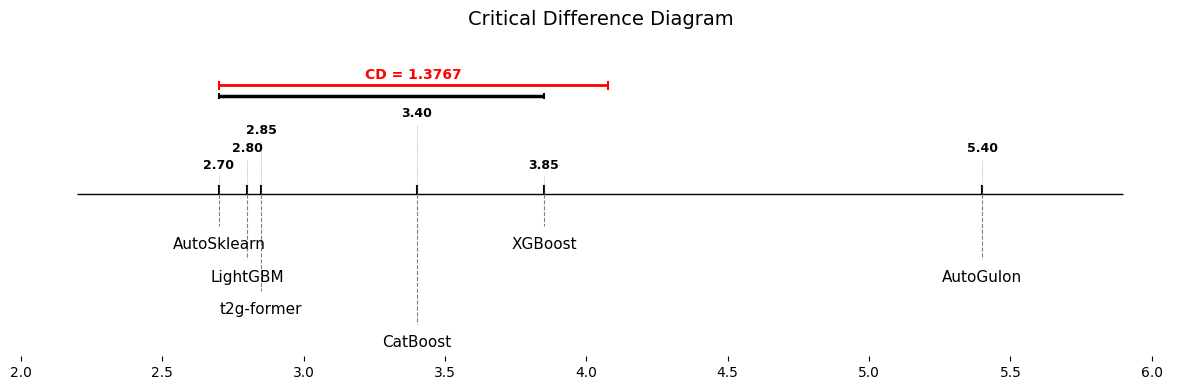

In [255]:
def plot_cd_diagram_robust(avg_ranks, cd, title="Critical Difference Diagram"):
    sorted_ranks = sorted(avg_ranks.items(), key=lambda x: x[1])
    models = [item[0] for item in sorted_ranks]
    ranks = np.array([item[1] for item in sorted_ranks])
    k = len(models)

    groups = []

    for i in range(k):
        for j in range(k-1, i, -1):
            if ranks[j] - ranks[i] < cd:
                groups.append((i, j))
                break
    
    final_groups = []

    for g1 in groups:
        is_subgroup = False

        for g2 in groups:
            if g1 != g2 and g1[0] >= g2[0] and g1[1] <= g2[1]:
                is_subgroup = True
                break

        if not is_subgroup:
            final_groups.append(g1)
            
    fig, ax = plt.subplots(figsize=(12, 4)) 
    
    x_min = ranks.min()
    x_max = ranks.max()
    ax.set_xlim(x_min - 0.7, x_max + 0.7)
    ax.set_ylim(0.0, 1.4)
    
    main_line_y = 0.75 
    
    ax.hlines(main_line_y, x_min - 0.5, x_max + 0.5, color="black", linewidth=1)
    
    text_levels = [0.2, 0.35, 0.50, 0.65]
    rank_levels = [0.1, 0.18, 0.26, 0.34]
    
    for i, (model, r) in enumerate(zip(models, ranks)):
        lvl_idx = i % 4 
        
        ax.vlines(r, main_line_y, main_line_y + 0.04, color="black")
        
        rank_y = main_line_y + rank_levels[lvl_idx]
        ax.text(r, rank_y, f"{r:.2f}", ha="center", va="bottom", fontsize=9, fontweight='bold')
        ax.plot([r, r], [main_line_y, rank_y - 0.02], color="gray", linestyle=":", linewidth=0.5)
        
        model_y = main_line_y - text_levels[lvl_idx]
        ax.text(r, model_y, model, ha="center", va="top", fontsize=11)
        ax.plot([r, r], [main_line_y, model_y + 0.05], color="gray", linestyle="--", linewidth=0.8)


    cd_y = 1.25
    ax.hlines(cd_y, x_min, x_min + cd, color="red", linewidth=2)
    ax.vlines(x_min, cd_y - 0.02, cd_y + 0.02, color="red")
    ax.vlines(x_min + cd, cd_y - 0.02, cd_y + 0.02, color="red")
    ax.text(x_min + cd/2, cd_y + 0.03, f"CD = {cd:.4f}", ha="center", color="red", fontweight='bold')

    base_group_y = main_line_y + 0.45 
    step_y = 0.08
    
    final_groups.sort(key=lambda x: x[1]-x[0]) 
    occupied_levels = [] 

    for start_idx, end_idx in final_groups:
        left_val = ranks[start_idx]
        right_val = ranks[end_idx]
        
        level = 0

        while True:
            collision = False

            for (occ_left, occ_right, occ_level) in occupied_levels:
                if occ_level == level:
                    if not (right_val < occ_left - 0.05 or left_val > occ_right + 0.05):
                        collision = True
                        break

            if not collision:
                break

            level += 1
        
        occupied_levels.append((left_val, right_val, level))
        
        y_pos = base_group_y + level * step_y
        ax.hlines(y_pos, left_val, right_val, color="black", linewidth=2.5)
        ax.vlines(left_val, y_pos - 0.015, y_pos + 0.015, color="black")
        ax.vlines(right_val, y_pos - 0.015, y_pos + 0.015, color="black")

    ax.set_yticks([])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.set_title(title, fontsize=14, pad=20)
    
    plt.tight_layout()
    plt.show()

avg_ranks = {
    "AutoSklearn": 2.70,
    "t2g-former": 2.85,
    "LightGBM": 2.80,
    "AutoGulon": 5.40,
    "CatBoost": 3.40,
    "XGBoost": 3.85
}  

cd = 1.3767

plot_cd_diagram_robust(avg_ranks, cd)

### other plots

In [127]:
df = test_results

metrics = ["auc_ovo", "mean_acc", "g_mean", "mean_cross_entropy"]

results = {}
for m in metrics:
    results[m] = df[df["split"]=="test"].groupby("nome_modelo")[m].mean().sort_values(ascending=False)

pd.DataFrame(results)


,auc_ovo,mean_acc,g_mean,mean_cross_entropy
nome_modelo,,,,
AutoGulon,0.847503,0.749641,0.440356,0.815753
AutoSklearn,0.874283,0.835531,0.717069,0.588114
LightGBM,0.876454,0.823081,0.729805,0.647714
t2g-former,0.883517,0.815395,0.722126,0.422704


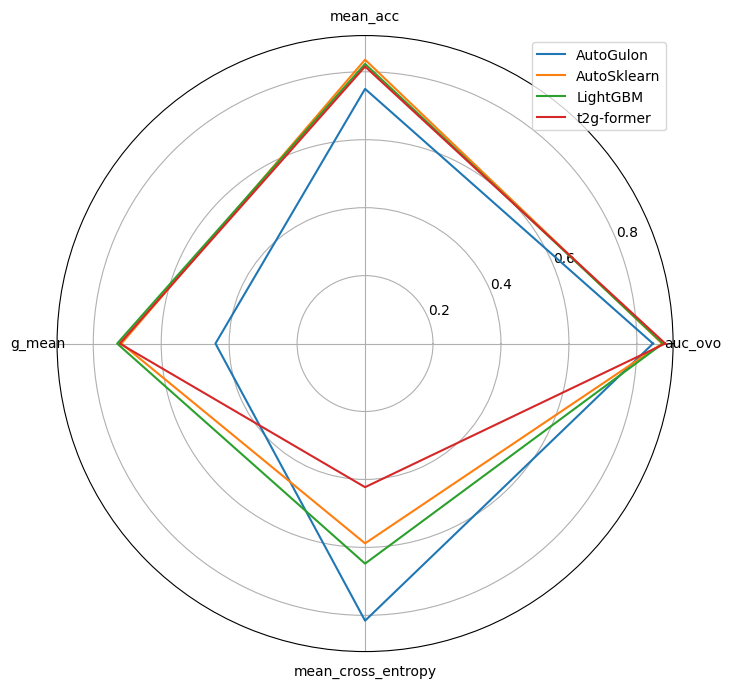

In [131]:
import matplotlib.pyplot as plt
import numpy as np

df = test_results
test = df[df["split"]=="test"].groupby("nome_modelo").mean(numeric_only=True)

metrics = ["auc_ovo","mean_acc","g_mean","mean_cross_entropy"]
labels = metrics

values = test[metrics].values.tolist()
names = test.index.tolist()

angles = np.linspace(0, 2*np.pi, len(labels), endpoint=False).tolist()
angles += angles[:1]

plt.figure(figsize=(8,8))
ax = plt.subplot(111, polar=True)

for i, name in enumerate(names):
    v = values[i]
    v = np.concatenate((v,[v[0]]))
    ax.plot(angles, v, label=name)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels)
plt.legend()
plt.show()

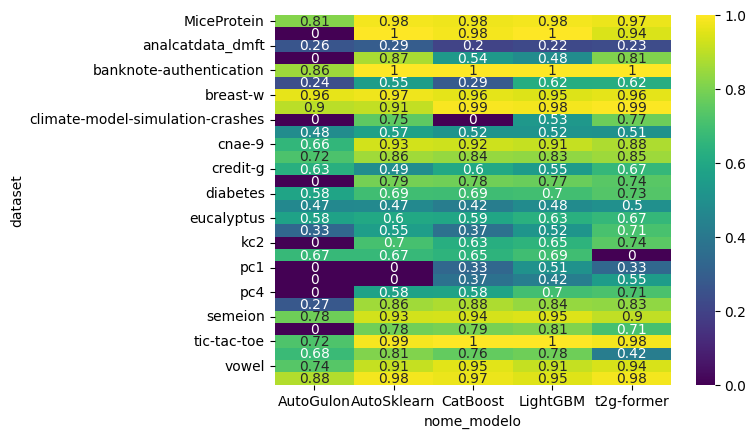

In [189]:
pivot = df[df["split"]=="test"].pivot(index="dataset", columns="nome_modelo", values="g_mean")

sns.heatmap(pivot, annot=True, cmap="viridis")
plt.show()

# T2G analysis

## train

In [136]:
train_results_t2g = train_results[train_results["nome_modelo"]=="t2g-former"]
train_results_t2g.head()

,split,nome_modelo,dataset,tempo_tune,tempo_train,auc_ovo,mean_acc,g_mean,mean_cross_entropy,tempo_predict
60,train,t2g-former,breast-w,NaN,6.944220,0.997688,0.986364,0.987954,0.049157,0.054291
62,train,t2g-former,eucalyptus,NaN,20.159727,0.950107,0.791429,0.785424,0.518641,0.130531
64,train,t2g-former,wdbc,NaN,11.679057,0.998339,0.988827,0.986607,0.037866,0.132891
66,train,t2g-former,pc4,NaN,98.836847,0.971814,0.931373,0.833790,0.142411,0.875363
68,train,t2g-former,credit-g,NaN,6.149773,0.844965,0.815873,0.763800,0.437383,0.055580


In [142]:
# computar médias gerais
train_means = train_results_t2g.mean(numeric_only=True).reset_index()
train_means

,index,0
0,tempo_tune,NaN
1,tempo_train,152.265806
2,auc_ovo,0.929302
3,mean_acc,0.871490
4,g_mean,0.797996
5,mean_cross_entropy,0.292221
6,tempo_predict,0.851456


## test

In [143]:
test_results_t2g = test_results[test_results["nome_modelo"]=="t2g-former"]
test_results_t2g.head()

,split,nome_modelo,dataset,tempo_tune,tempo_train,auc_ovo,mean_acc,g_mean,mean_cross_entropy,tempo_predict
61,test,t2g-former,breast-w,NaN,6.944220,0.997495,0.966667,0.959464,0.071384,0.026746
63,test,t2g-former,eucalyptus,NaN,20.159727,0.894167,0.670659,0.666223,0.794102,0.057600
65,test,t2g-former,wdbc,NaN,11.679057,0.996914,0.982456,0.982803,0.056560,0.058383
67,test,t2g-former,pc4,NaN,98.836847,0.903672,0.888128,0.714765,0.266937,0.494645
69,test,t2g-former,credit-g,NaN,6.149773,0.789369,0.756667,0.666947,0.509553,0.021997


In [144]:
test_means = test_results_t2g.mean(numeric_only=True).reset_index()
test_means

,index,0
0,tempo_tune,NaN
1,tempo_train,152.265806
2,auc_ovo,0.883517
3,mean_acc,0.815395
4,g_mean,0.722126
5,mean_cross_entropy,0.422704
6,tempo_predict,0.380687


# light gbm

## train

In [145]:
train_results_lightgbm = train_results[train_results["nome_modelo"]=="LightGBM"]
train_results_lightgbm.head()

,split,nome_modelo,dataset,tempo_tune,tempo_train,auc_ovo,mean_acc,g_mean,mean_cross_entropy,tempo_predict
180,train,LightGBM,steel-plates-fault,463.52,183.67,0.966584,0.795267,0.803120,1.120667,55.16
182,train,LightGBM,tic-tac-toe,38.19,18.37,1.000000,1.000000,1.000000,0.002802,5.68
184,train,LightGBM,banknote-authentication,26.37,13.14,0.999824,0.994792,0.994835,0.020773,5.87
186,train,LightGBM,diabetes,26.91,10.45,0.810234,0.765479,0.696784,0.511551,2.81
188,train,LightGBM,ilpd,21.42,7.36,0.720554,0.720610,0.602467,0.957207,2.99


In [147]:
train_means = train_results_lightgbm.mean(numeric_only=True).reset_index()
train_means

,index,0
0,tempo_tune,127.388000
1,tempo_train,50.339000
2,auc_ovo,0.889410
3,mean_acc,0.837479
4,g_mean,0.755742
5,mean_cross_entropy,0.585106
6,tempo_predict,20.265333


## test

In [148]:
test_results_lightgbm = test_results[test_results["nome_modelo"]=="LightGBM"]
test_results_lightgbm.head()

,split,nome_modelo,dataset,tempo_tune,tempo_train,auc_ovo,mean_acc,g_mean,mean_cross_entropy,tempo_predict
181,test,LightGBM,steel-plates-fault,463.52,183.67,0.967754,0.809605,0.810460,1.137946,55.16
183,test,LightGBM,tic-tac-toe,38.19,18.37,1.000000,1.000000,1.000000,0.000871,5.68
185,test,LightGBM,banknote-authentication,26.37,13.14,1.000000,0.997573,0.997814,0.013428,5.87
187,test,LightGBM,diabetes,26.91,10.45,0.845350,0.761905,0.696552,0.472482,2.81
189,test,LightGBM,ilpd,21.42,7.36,0.671840,0.640000,0.520308,1.092010,2.99


In [149]:
test_means = test_results_lightgbm.mean(numeric_only=True).reset_index()
test_means

,index,0
0,tempo_tune,127.388000
1,tempo_train,50.339000
2,auc_ovo,0.876454
3,mean_acc,0.823081
4,g_mean,0.729805
5,mean_cross_entropy,0.647714
6,tempo_predict,20.265333


# ASKL

## treino

In [150]:
train_results_autosklearn = train_results[train_results["nome_modelo"]=="AutoSklearn"]
train_results_autosklearn.head()

,split,nome_modelo,dataset,tempo_tune,tempo_train,auc_ovo,mean_acc,g_mean,mean_cross_entropy,tempo_predict
0,train,AutoSklearn,breast-w,NaN,65.920298,0.998384,0.990909,0.991514,0.062397,0.413152
2,train,AutoSklearn,eucalyptus,NaN,56.530461,0.954334,0.825714,0.789756,0.665422,3.786953
4,train,AutoSklearn,wdbc,NaN,54.669093,0.996147,0.988827,0.986607,0.075828,0.423970
6,train,AutoSklearn,pc4,NaN,115.232249,0.990809,0.969499,0.890082,0.224395,5.328887
8,train,AutoSklearn,credit-g,NaN,294.931927,0.925386,0.853968,0.727698,0.598647,0.519495


In [151]:
train_means = train_results_autosklearn.mean(numeric_only=True).reset_index()
train_means

,index,0
0,tempo_tune,NaN
1,tempo_train,171.176978
2,auc_ovo,0.944774
3,mean_acc,0.914652
4,g_mean,0.842496
5,mean_cross_entropy,0.478615
6,tempo_predict,7.595749


## teste

In [152]:
test_results_autosklearn = test_results[test_results["nome_modelo"]=="AutoSklearn"]
test_results_autosklearn.head()

,split,nome_modelo,dataset,tempo_tune,tempo_train,auc_ovo,mean_acc,g_mean,mean_cross_entropy,tempo_predict
1,test,AutoSklearn,breast-w,NaN,65.920298,0.997808,0.976190,0.974575,0.089550,0.332620
3,test,AutoSklearn,eucalyptus,NaN,56.530461,0.870681,0.670659,0.600649,0.854149,3.711598
5,test,AutoSklearn,wdbc,NaN,54.669093,0.998089,0.988304,0.983999,0.079230,0.406010
7,test,AutoSklearn,pc4,NaN,115.232249,0.927329,0.897260,0.577596,0.310648,3.910934
9,test,AutoSklearn,credit-g,NaN,294.931927,0.772701,0.733333,0.488094,0.627840,0.322403


In [153]:
test_means = test_results_autosklearn.mean(numeric_only=True).reset_index()
test_means

,index,0
0,tempo_tune,NaN
1,tempo_train,171.176978
2,auc_ovo,0.874283
3,mean_acc,0.835531
4,g_mean,0.717069
5,mean_cross_entropy,0.588114
6,tempo_predict,4.238546


# autogluon

## train

In [154]:
train_results_autogluon = train_results[train_results["nome_modelo"]=="AutoGulon"]
train_results_autogluon.head()

,split,nome_modelo,dataset,tempo_tune,tempo_train,auc_ovo,mean_acc,g_mean,mean_cross_entropy,tempo_predict
120,train,AutoGulon,steel-plates-fault,5486.285083,1608.184825,0.935243,0.681236,0.428023,1.034673,1048.626811
122,train,AutoGulon,tic-tac-toe,1004.654372,246.213966,0.827572,0.788060,0.569914,0.466404,65.835176
124,train,AutoGulon,banknote-authentication,915.000458,244.959011,0.985465,0.871875,0.838871,0.562504,266.000327
126,train,AutoGulon,diabetes,998.002842,350.846302,0.799148,0.698463,0.402037,0.550584,70.992060
128,train,AutoGulon,ilpd,1075.668596,244.830439,0.670752,0.676829,0.242591,0.602235,69.499949


In [155]:
train_means = train_results_autogluon.mean(numeric_only=True).reset_index()
train_means

,index,0
0,tempo_tune,2078.851788
1,tempo_train,573.673361
2,auc_ovo,0.838251
3,mean_acc,0.745067
4,g_mean,0.404518
5,mean_cross_entropy,0.812158
6,tempo_predict,243.653563


## test

In [156]:
test_results_autogluon = test_results[test_results["nome_modelo"]=="AutoGulon"]
test_results_autogluon.head()

,split,nome_modelo,dataset,tempo_tune,tempo_train,auc_ovo,mean_acc,g_mean,mean_cross_entropy,tempo_predict
121,test,AutoGulon,steel-plates-fault,5486.285083,1608.184825,0.955255,0.591767,0.000000,1.242132,1048.626811
123,test,AutoGulon,tic-tac-toe,1004.654372,246.213966,0.956277,0.829861,0.719190,0.425318,65.835176
125,test,AutoGulon,banknote-authentication,915.000458,244.959011,0.968168,0.873786,0.855013,0.563014,266.000327
127,test,AutoGulon,diabetes,998.002842,350.846302,0.818025,0.744589,0.584223,0.542056,70.992060
129,test,AutoGulon,ilpd,1075.668596,244.830439,0.628800,0.685714,0.330817,0.682238,69.499949


In [157]:
test_means = test_results_autogluon.mean(numeric_only=True).reset_index()
test_means

,index,0
0,tempo_tune,2078.851788
1,tempo_train,573.673361
2,auc_ovo,0.847503
3,mean_acc,0.749641
4,g_mean,0.440356
5,mean_cross_entropy,0.815753
6,tempo_predict,243.653563


# CatBoost

## treino

In [190]:
train_results_catboost = train_results[train_results["nome_modelo"]=="CatBoost"]
train_results_catboost.head()

,split,nome_modelo,dataset,tempo_tune,tempo_train,auc_ovo,mean_acc,g_mean,mean_cross_entropy,tempo_predict
240,train,CatBoost,credit-approval,14.668849,0.014622,0.970018,0.914747,0.915469,0.249339,0.000187
242,train,CatBoost,dresses-sales,18.087480,0.027985,0.994103,0.939683,0.926759,0.328006,0.000168
244,train,CatBoost,mfeat-morphological,99.186992,0.203404,0.987884,0.838095,0.815146,0.405665,0.000584
246,train,CatBoost,vehicle,75.901436,0.041750,0.992620,0.941729,0.940630,0.334969,0.000295
248,train,CatBoost,banknote-authentication,40.088494,0.233166,1.000000,1.000000,1.000000,0.000086,0.000474


In [191]:
train_means = train_results_catboost.mean(numeric_only=True).reset_index()
train_means

,index,0
0,tempo_tune,231.346588
1,tempo_train,1.475538
2,auc_ovo,0.968332
3,mean_acc,0.928844
4,g_mean,0.895883
5,mean_cross_entropy,0.211304
6,tempo_predict,0.000478


## test

In [192]:
test_results_catboost = test_results[test_results["nome_modelo"]=="CatBoost"]
test_results_catboost.head()

,split,nome_modelo,dataset,tempo_tune,tempo_train,auc_ovo,mean_acc,g_mean,mean_cross_entropy,tempo_predict
241,test,CatBoost,credit-approval,14.668849,0.014622,0.928022,0.840580,0.842020,0.347480,0.000108
243,test,CatBoost,dresses-sales,18.087480,0.027985,0.518154,0.526667,0.418510,0.743947,0.000110
245,test,CatBoost,mfeat-morphological,99.186992,0.203404,0.963341,0.710000,0.645019,0.641938,0.000773
247,test,CatBoost,vehicle,75.901436,0.041750,0.940860,0.795276,0.761709,0.476767,0.000184
249,test,CatBoost,banknote-authentication,40.088494,0.233166,1.000000,1.000000,1.000000,0.000357,0.000277


In [194]:
test_means = test_results_catboost.mean(numeric_only=True).reset_index()
test_means

,index,0
0,tempo_tune,231.346588
1,tempo_train,1.475538
2,auc_ovo,0.892748
3,mean_acc,0.826204
4,g_mean,0.683756
5,mean_cross_entropy,0.376777
6,tempo_predict,0.000353


# XGBOOST

## train

In [223]:
train_results_xgboost = train_results[train_results["nome_modelo"]=="XGBoost"]
train_results_xgboost.head()

,split,nome_modelo,dataset,tempo_tune,tempo_train,auc_ovo,mean_acc,g_mean,mean_cross_entropy,tempo_predict
300,train,XGBoost,credit-approval,0.885204,0.009274,0.955406,0.895740,0.896606,0.285656,0.000788
302,train,XGBoost,dresses-sales,1.006498,0.016758,0.989077,0.938889,0.934227,0.230279,0.002150
304,train,XGBoost,mfeat-morphological,6.023089,0.142793,0.988890,0.843254,0.832287,0.555562,0.037877
306,train,XGBoost,breast-w,0.708433,0.009078,0.993348,0.974432,0.974122,0.099632,0.000588
308,train,XGBoost,eucalyptus,2.544368,0.017952,0.952422,0.765714,0.696977,0.659137,0.000847


In [224]:
train_means = train_results_xgboost.mean(numeric_only=True).reset_index()
train_means

,index,0
0,tempo_tune,5.857297
1,tempo_train,0.121745
2,auc_ovo,0.958888
3,mean_acc,0.910621
4,g_mean,0.832759
5,mean_cross_entropy,0.264407
6,tempo_predict,0.006966


## test

In [225]:
test_results_xgboost = test_results[test_results["nome_modelo"]=="XGBoost"]
test_results_xgboost.head()

,split,nome_modelo,dataset,tempo_tune,tempo_train,auc_ovo,mean_acc,g_mean,mean_cross_entropy,tempo_predict
301,test,XGBoost,credit-approval,0.885204,0.009274,0.932225,0.875541,0.876076,0.329028,0.000310
303,test,XGBoost,dresses-sales,1.006498,0.016758,0.637561,0.584127,0.557584,0.818082,0.000669
305,test,XGBoost,mfeat-morphological,6.023089,0.142793,0.962758,0.737302,0.694314,0.745913,0.009589
307,test,XGBoost,breast-w,0.708433,0.009078,0.990678,0.965909,0.963290,0.124372,0.000282
309,test,XGBoost,eucalyptus,2.544368,0.017952,0.840330,0.585714,0.468869,0.929183,0.000348


In [226]:
test_means = test_results_xgboost.mean(numeric_only=True).reset_index()
test_means

,index,0
0,tempo_tune,5.857297
1,tempo_train,0.121745
2,auc_ovo,0.879683
3,mean_acc,0.813359
4,g_mean,0.672475
5,mean_cross_entropy,0.442162
6,tempo_predict,0.001901
